# How are in-demand skills trending for Data Analysts?

### Methodology

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs 
3. Plot the monthly skill demand

In [ ]:
# Importing Libraries 
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import FuncFormatter
from adjustText import adjust_text

In [4]:
# Loading Dataset
raw = load_dataset('lukebarousse/data_jobs')
df = raw['train'].to_pandas().copy()

In [5]:
# Data Cleaning
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [6]:
# adding month column
df['job_posted_month'] = df['job_posted_date'].dt.month

In [7]:
# Exploding the skill column
df_explode = df.explode('job_skills').copy()

In [8]:
# Filtering for Data Analyst in the US
df_DA_US = df_explode[(df_explode['job_title_short'] == 'Data Analyst') & (df_explode['job_country']=='United States')]

In [9]:
df_DA_US_Pivot = df_DA_US.pivot_table(index='job_posted_month',columns='job_skills',aggfunc='size',fill_value=0)
df_DA_US_Pivot.loc['total'] = df_DA_US_Pivot.sum()
df_DA_US_Pivot = df_DA_US_Pivot[df_DA_US_Pivot.loc['total'].sort_values(ascending=False).index]
df_DA_US_Pivot.drop(labels='total',axis=0,inplace = True)
df_DA_US_Pivot

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,4601,3592,2488,2254,1832,1513,1337,968,972,718,...,1,0,0,0,0,0,0,0,0,0
2,3168,2587,1676,1618,1212,1045,1122,738,705,514,...,0,0,0,0,0,0,0,0,0,0
3,3226,2661,1804,1683,1238,1141,1054,736,669,418,...,0,0,0,0,0,0,0,0,0,1
4,3220,2549,1789,1679,1302,1038,1057,695,650,439,...,0,0,0,0,0,0,0,0,0,0
5,2581,2118,1432,1349,972,867,860,557,515,358,...,0,0,0,0,0,1,0,0,0,0
6,2862,2382,1628,1609,984,1017,989,721,624,414,...,0,0,0,1,0,0,1,1,0,0
7,2609,2118,1533,1438,996,881,881,587,549,401,...,0,0,0,0,0,0,0,0,0,0
8,3414,2731,1951,2025,1276,1271,1208,752,746,484,...,0,0,0,0,0,0,0,0,0,0
9,2295,1801,1353,1229,856,746,820,478,475,359,...,0,0,0,0,0,0,0,0,0,0


In [10]:
df_totals = df_DA_US.groupby('job_posted_month').agg('size').reset_index(name='job_counts').set_index('job_posted_month')
df_totals

,job_counts
job_posted_month,
1,32489
2,23196
3,23271
4,23311
5,18803
6,21418
7,19664
8,25621
9,17489


In [11]:
df_skill_perc = df_DA_US_Pivot.div(df_totals['job_counts']/100,axis=0)
df_skill_perc.reset_index(inplace=True)
df_skill_perc['job_posted_month'] = df_skill_perc['job_posted_month'].apply(lambda x : pd.to_datetime(x, format='%m').strftime('%b'))
df_skill_perc.set_index('job_posted_month',inplace= True)
df_skill_perc

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,14.161716,11.056050,7.657977,6.937733,5.638832,4.656961,4.115239,2.979470,2.991782,2.209979,...,0.003078,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,13.657527,11.152785,7.225384,6.975341,5.225039,4.505087,4.837041,3.181583,3.039317,2.215899,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,13.862748,11.434833,7.752138,7.232177,5.319926,4.903098,4.529242,3.162735,2.874823,1.796227,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004297
Apr,13.813221,10.934752,7.674488,7.202608,5.585346,4.452833,4.534340,2.981425,2.788383,1.883231,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,13.726533,11.264160,7.615806,7.174387,5.169388,4.610966,4.573738,2.962293,2.738925,1.903951,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.005318,0.000000,0.000000,0.000000,0.000000
Jun,13.362592,11.121487,7.601083,7.512373,4.594267,4.748343,4.617611,3.366327,2.913437,1.932954,...,0.000000,0.000000,0.000000,0.004669,0.000000,0.000000,0.004669,0.004669,0.000000,0.000000
Jul,13.267901,10.770952,7.795972,7.312856,5.065094,4.480269,4.480269,2.985151,2.791904,2.039260,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,13.325007,10.659225,7.614847,7.903673,4.980290,4.960774,4.714882,2.935092,2.911674,1.889075,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,13.122534,10.297902,7.736291,7.027274,4.894505,4.265538,4.688661,2.733147,2.715993,2.052719,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
df_plot = df_skill_perc.iloc[:,:5]
df_plot

job_skills,sql,excel,tableau,python,sas
job_posted_month,,,,,
Jan,14.161716,11.056050,7.657977,6.937733,5.638832
Feb,13.657527,11.152785,7.225384,6.975341,5.225039
Mar,13.862748,11.434833,7.752138,7.232177,5.319926
Apr,13.813221,10.934752,7.674488,7.202608,5.585346
May,13.726533,11.264160,7.615806,7.174387,5.169388
Jun,13.362592,11.121487,7.601083,7.512373,4.594267
Jul,13.267901,10.770952,7.795972,7.312856,5.065094
Aug,13.325007,10.659225,7.614847,7.903673,4.980290
Sep,13.122534,10.297902,7.736291,7.027274,4.894505


In [13]:
# plt.figure(figsize=(8,6))
# sns.lineplot(data=df_plot,dashes=False,palette='tab10')
# sns.set_theme(style='ticks')
# sns.despine()

# plt.title('Trending Top Skills for Data Analyst in the US',fontsize=15,fontweight='bold')
# plt.xlabel('2023')
# plt.ylabel('Likelihood in Job Posting')
# plt.legend().remove()

# for i in range(5):
#    plt.text(11.2,df_plot.iloc[-1,i],df_plot.columns[i])

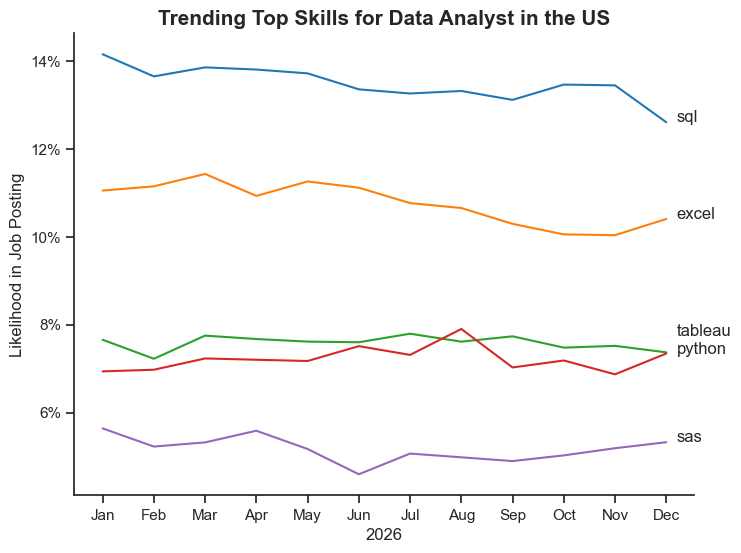

In [21]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df_plot,dashes=False,palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analyst in the US',fontsize=15,fontweight='bold')
plt.xlabel('2026')
plt.ylabel('Likelihood in Job Posting')
plt.legend().remove()

axis = plt.gca()
axis.yaxis.set_major_formatter(PercentFormatter(decimals=0))

y_positions = df_plot.iloc[-1].values.copy()
sorted_idx = y_positions.argsort()
for j in range(1, len(sorted_idx)):
    if y_positions[sorted_idx[j]] - y_positions[sorted_idx[j-1]] < 0.4:
        y_positions[sorted_idx[j]] = y_positions[sorted_idx[j-1]] + 0.4

for i in range(5):
    plt.text(11.2, y_positions[i], df_plot.columns[i])

